In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

## Regresja drzewami decyzyjnymi

### Tworzymy sztuczne dane

In [2]:
np.random.seed(42)
N = 30
x = np.random.normal(170,20,N).round(0)
y = x + np.random.normal(5,25,N).round(0)
z = (x+y + 0.01*x*y+ np.random.normal(2,12,N)).round(0)

In [3]:
df = pd.DataFrame({
    'X_1':x,
    'X_2':y,
    'price':z})

In [4]:
df

,X_1,X_2,price
0,180.0,170.0,652.0
1,167.0,218.0,749.0
2,183.0,188.0,704.0
3,200.0,179.0,725.0
4,165.0,191.0,683.0
5,165.0,139.0,552.0
6,202.0,212.0,843.0
7,185.0,141.0,601.0
8,161.0,133.0,514.0
9,181.0,191.0,712.0


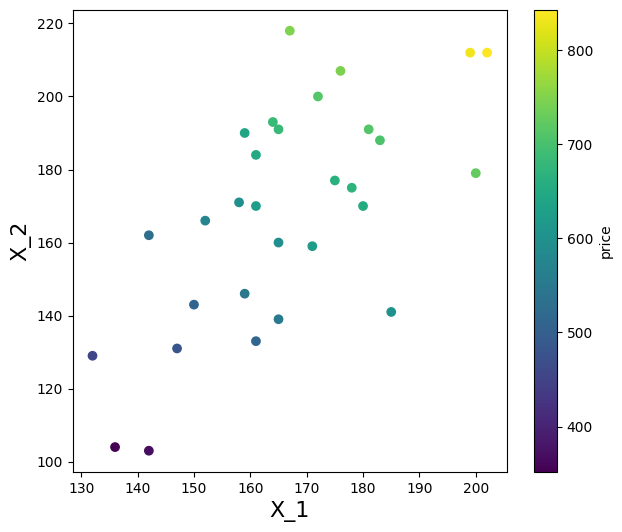

In [5]:
plt.figure(figsize=(7, 6))
plt.scatter('X_1','X_2',data=df,c='price')
plt.xlabel('X_1',size=16)
plt.ylabel('X_2',size=16)
plt.colorbar(label='price')
#plt.title('Scatter Plot')
plt.show()

In [6]:
X = df.drop(columns='price')
y = df['price']

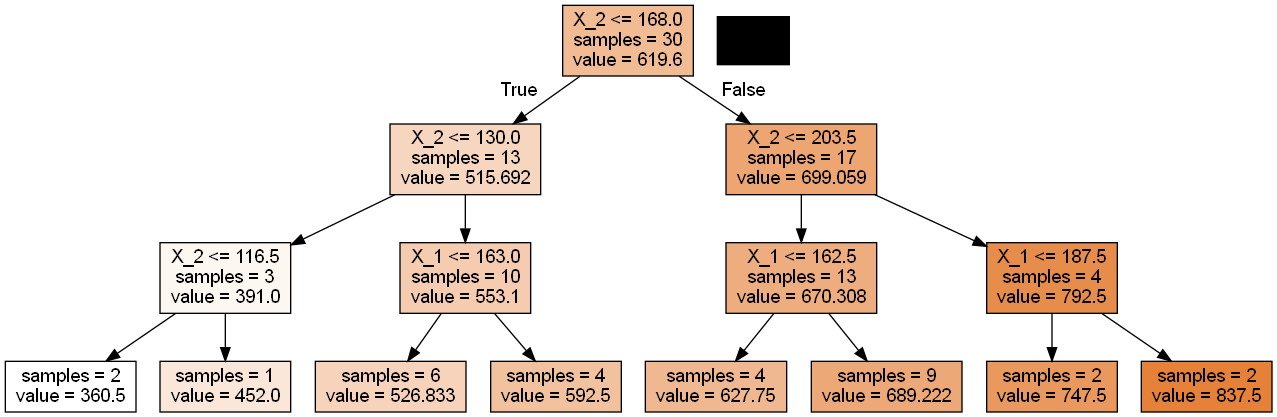

In [7]:
from sklearn import tree

rgtree = tree.DecisionTreeRegressor(max_depth=3)
rgtree.fit(X, y)
dot_data = tree.export_graphviz(rgtree, feature_names=X.columns, out_file=None, 
                                filled=True,impurity=False)
from IPython.display import Image
import pydotplus
import graphviz
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

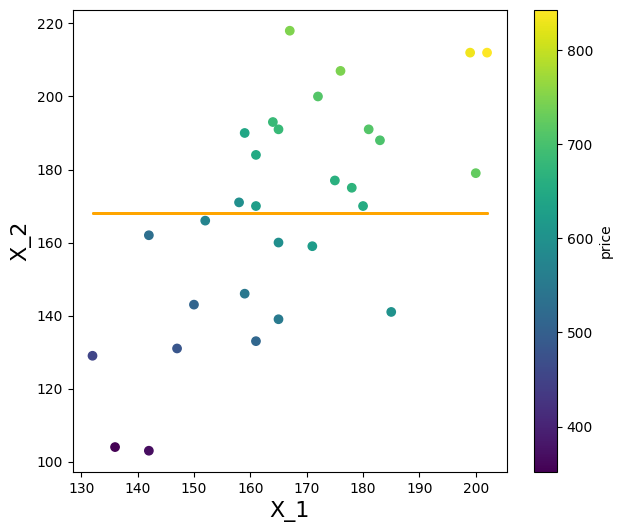

In [8]:
x1 = df['X_1']
y1 = df['X_2']
plt.figure(figsize=(7, 6))
plt.scatter('X_1','X_2',data=df,c='price')
plt.xlabel('X_1',size=16)
plt.ylabel('X_2',size=16)
plt.plot(x1,168+0*x1,lw=2,ls='-',c='orange')
plt.colorbar(label='price')
plt.show()

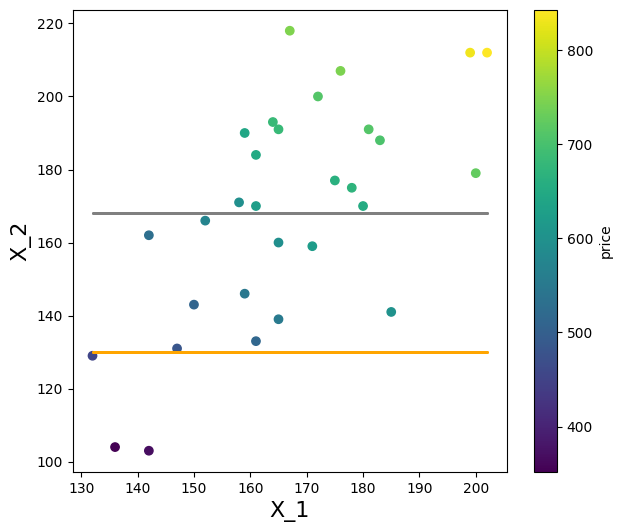

In [9]:
x1 = df['X_1']
y1 = df['X_2']
plt.figure(figsize=(7, 6))
plt.scatter('X_1','X_2',data=df,c='price')
plt.colorbar(label='price')
plt.xlabel('X_1',size=16)
plt.ylabel('X_2',size=16)
plt.plot(x1,168+0*x1,lw=2,ls='-',c='gray')
plt.plot(x1,130+0*x1,lw=2,ls='-',c='orange')
plt.show()

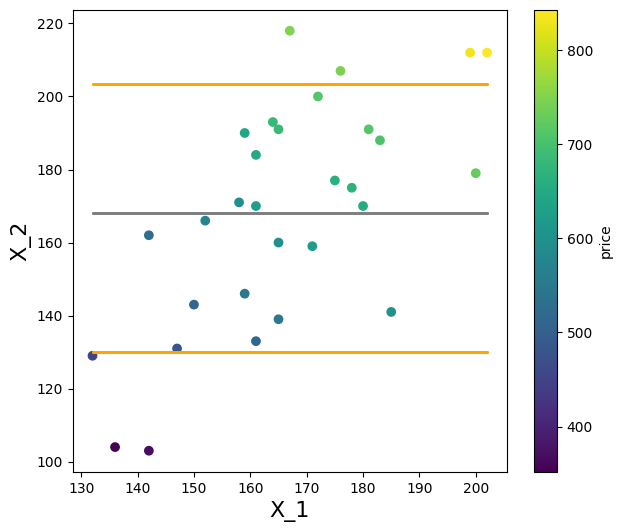

In [10]:
#x1 = df['X']
#y1 = df['Y']
plt.figure(figsize=(7, 6))
plt.scatter('X_1','X_2',data=df,c='price')
plt.colorbar(label='price')
plt.xlabel('X_1',size=16)
plt.ylabel('X_2',size=16)
plt.plot(x1,168+0*x1,lw=2,ls='-',c='gray')
plt.plot(x1,130+0*x1,lw=2,ls='-',c='orange')
plt.plot(x1,203.5+0*x1,lw=2,ls='-',c='orange')
plt.show()

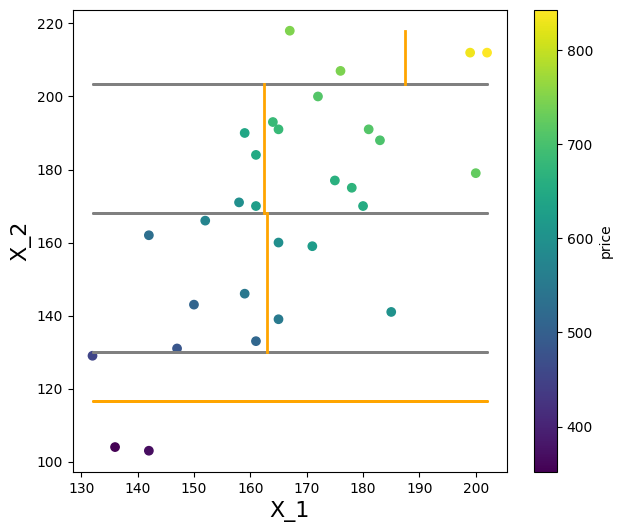

In [11]:
#x1 = df['X']
#y1 = df['Y']
plt.figure(figsize=(7, 6))
plt.scatter('X_1','X_2',data=df,c='price')
plt.colorbar(label='price')
plt.xlabel('X_1',size=16)
plt.ylabel('X_2',size=16)
plt.plot(x1,168+0*x1,lw=2,ls='-',c='gray')
plt.plot(x1,130+0*x1,lw=2,ls='-',c='gray')
plt.plot(x1,203.5+0*x1,lw=2,ls='-',c='gray')
plt.plot(x1,116.5+0*x1,lw=2,ls='-',c='orange')
plt.plot([163,163],[130,168],lw=2,ls='-',c='orange')
plt.plot([162.5,162.5],[168,203.5],lw=2,ls='-',c='orange')
plt.plot([187.5,187.5],[203.5,218],lw=2,ls='-',c='orange')
plt.show()

### Jak wybrać najlepszy podział?

Załóżmy, że w naszych danych jest $n$ cech. Dla danej **$j$-tej cechy** i **progu $t$** dzielimy dane na dwie części: $Q_\ell$ i $Q_r$.
* $Q_\ell$ składa się ze wszystkich próbek takich, że ich $j$-tą cechą jest $\leq t$.
* $Q_r$ składa się z pozostałych.

Aby ocenić, jak dobry jest podział, obliczamy tak zwany **średni błąd kwadratowy**:
$$
H(Q_\ell)=\frac{1}{N_\ell}\sum_{y\in Q_\ell}(y-\bar{y})^2,
$$
Gdzie
$$
\bar{y}=\frac{1}{N_\ell}\sum_{y\in Q_\ell}y.
$$
Podobnie obliczamy $H(Q_r)$

Impurity (zanieczyszczenie) dla podziału $j$-tej cechy i progu $t$ jest określone wzorem
$$
I(j,t)=\frac{N_{\ell}}{N}H(Q_{\ell}^{j,t})+\frac{N_{r}}{N}H(Q_{r }^{j,t})
$$
To jest ważont MSE dla podziału.

Małe zanieczyszczenie oznacza, że wartości na rozgałęzieniach są bardzo podobne. Naszym celem jest więc wybranie cechy $j^*$ i progu $t^*$, które minimalizują zanieczyszczenie:
$$
I(j^*,t^*)=\min_{j,t}I(j,t).
$$

Jeśli zmienna niezależna to **zliczone wartości** (np. liczba skarg klientów) lub częstotliwość (liczba na jednostkę), MSE może generować tendencyjne wyniki. W takich przypadkach należy rozważyć połówkowe odchylenie Poissona (half Poisson deviance):
$$
H(Q_\ell)=\frac{1}{N_\ell}\sum_{y\in Q_\ell}(y\log\frac{y}{\bar{y}_\ell}-y+\bar{y}_\ell).
$$
**Ograniczenia:** $y\geq 0$ dla tego modelu. Dopasowanie modelu znacznie wolniejsze niż przy zastosowaniu kryterium MSE

### Oposy

In [12]:
df = pd.read_csv('possum.csv')
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [13]:
df.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


In [14]:
oposy = df.drop(columns=['case'])
oposy['Pop'] = oposy['Pop'].map({'Vic': 1, 'other': 0})
oposy['sex'] = oposy['sex'].map({'f': 1, 'm': 0})
oposy = oposy.dropna(how = "any")
oposy

,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,0,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,1,1,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,1,1,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,1,1,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,1,1,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,7,0,0,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,7,0,0,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,7,0,1,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,7,0,0,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [15]:
X = oposy.drop(columns='age')
y = oposy['age']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

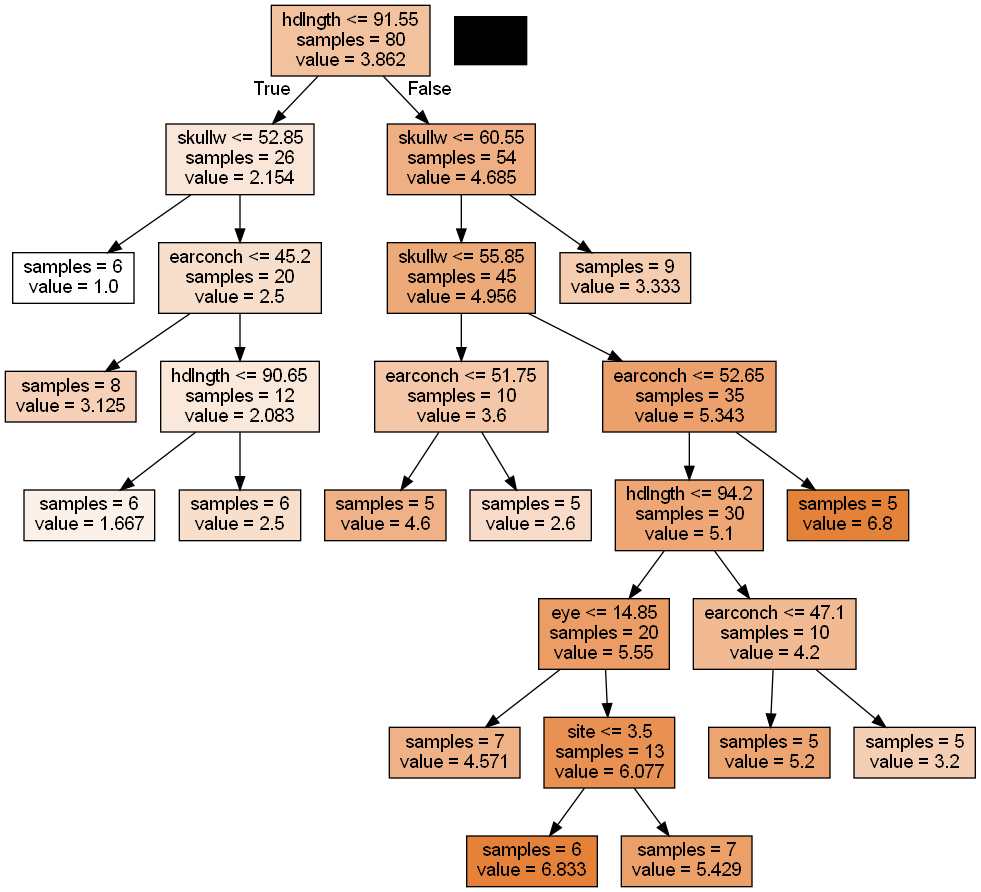

In [16]:
from sklearn import tree

rgtree = tree.DecisionTreeRegressor(min_samples_leaf=5)
rgtree.fit(X_train, y_train)
dot_data = tree.export_graphviz(rgtree, feature_names=X.columns, out_file=None, 
                                filled=True,impurity=False)
from IPython.display import Image
import pydotplus
import graphviz
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
errors = mean_squared_error(y_test,rgtree.predict(X_test)), mean_absolute_error(y_test,rgtree.predict(X_test))
print(errors)

(5.015177761580823, 1.919614512471655)


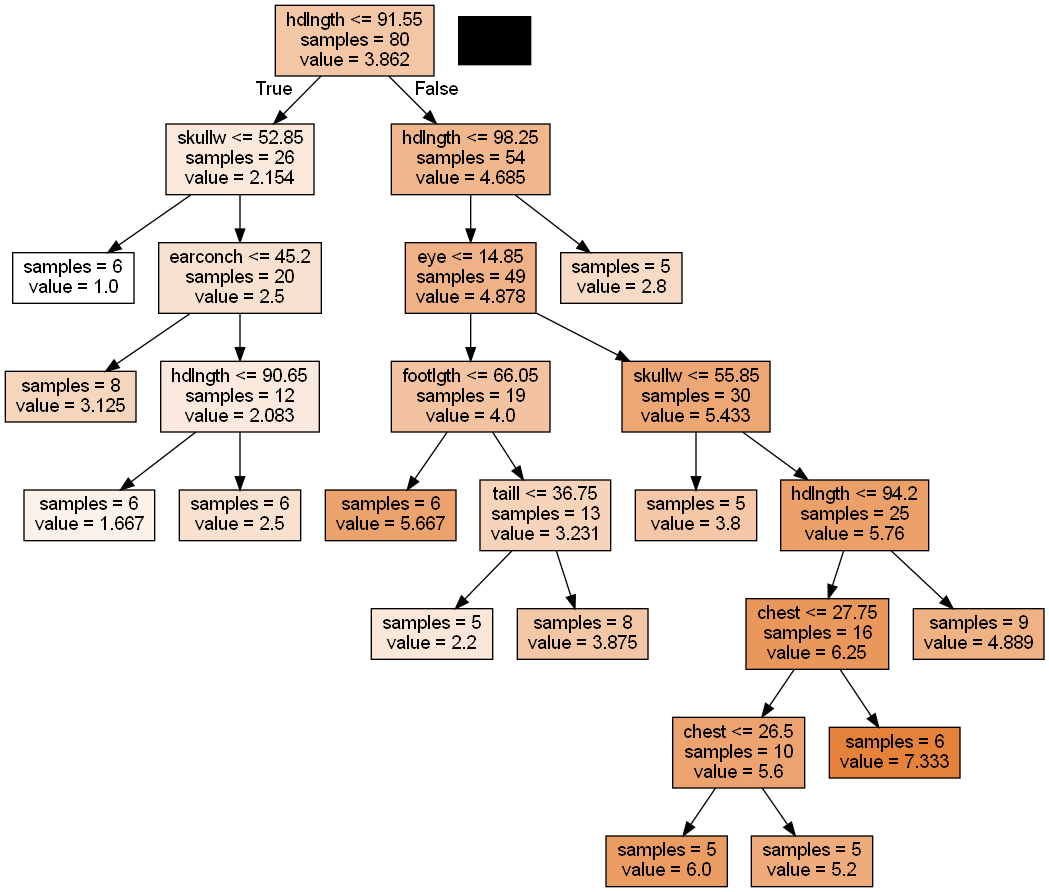

In [18]:
from sklearn import tree
# criterion{“squared_error”, “mse”, “friedman_mse”, “absolute_error”, “mae”, “poisson”},
rgtree = tree.DecisionTreeRegressor(min_samples_leaf=5, criterion="poisson")
rgtree.fit(X_train, y_train)
dot_data = tree.export_graphviz(rgtree, feature_names=X.columns, out_file=None, 
                                filled=True,impurity=False)
from IPython.display import Image
import pydotplus
import graphviz
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
errors = (mean_squared_error(y_test,rgtree.predict(X_test)), 
          mean_absolute_error(y_test,rgtree.predict(X_test)),
          r2_score(y_test,rgtree.predict(X_test)))
print(errors)

(3.103434744268078, 1.4806878306878306, -1.2734463824289408)


### Parameters of DecisionTreeRegressor

All parameters, but criterion of splitting, are very similar to that of DecisionTreeClassifier:
1. **criterion** - choosing a function measuring the split quality. Default value is 'squred_error' - Mean Squeared Error. Other values: 'friedman_mse' - Friedman version of MSE, 'absolute_error' - $H(Q)=\frac{1}{N}\sum_{y\in Q}\vert y-\text{median}_{y\in Q}(y)\vert$, 'poisson' - Half Poisson deviance.   
2. **splitter** - 'best' (default) or 'random' (for every feature $j$ draw treshold $t_j$ in random uniformly from the projection range, and find the best $t^*$ accoring to criterion). Random splitter is much faster but much more biased. To be used in ensemble methods.  
3. **max_depth** - the maximum depth of the tree
4.**min_samples_split** - the minimum number of samples required to split an internal node.
5. **min_samples_leaf** - the minimum number of samples required to be at a leaf node
6. **max_features** - the number of features to consider when looking for the best split: int, float or {'auto', 'sqrt', 'log2'}, default=None. If max_features < n_features the algorithm will select max_features at *random* at each split before finding the best split among them.

### Feature importance - znaczenie zmiennych

Elapsed time to compute the importances: 0.001 seconds


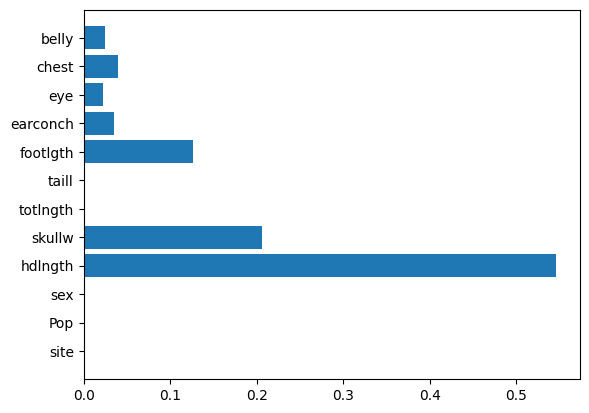

In [20]:
rgtree = tree.DecisionTreeRegressor(min_samples_leaf=5)
rgtree.fit(X,y)
start_time = time.time()
feature_importances = rgtree.feature_importances_
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: "
      f"{elapsed_time:.3f} seconds")
plt.barh(X.columns, feature_importances)
plt.show()

### Feature importance przy użyciu permuation variable importance measure


1. Wejście: dopasowany model predykcyjny $m$, tabelaryczny zbiór danych $D$.
2. Obliczmy miarę $s$ dla modelu $m$ na danych $D$ (na przykład dokładność dla klasyfikatora lub $R^2$ dla regresora).
3. Dla każdej cechy $j$ (kolumna $D$ ):
4. Dla każdego powtórzenia $k$ w $1, \ldots, K$ :
- Losowo przetasuj kolumnę $j$ zbioru danych $D$, aby wygenerować wersję danych o nazwie $\tilde{D}_{k, j}$.
- Oblicz wynik $s_{k, j}$ modelu $m$ na danych $\tilde{D}_{k, j}$.
- Oblicz ważność $i_j$ dla cechy $f_j$ zdefiniowanej jako:
$$
i_j=s-\frac{1}{K} \sum_{k=1}^K s_{k, j}
$$

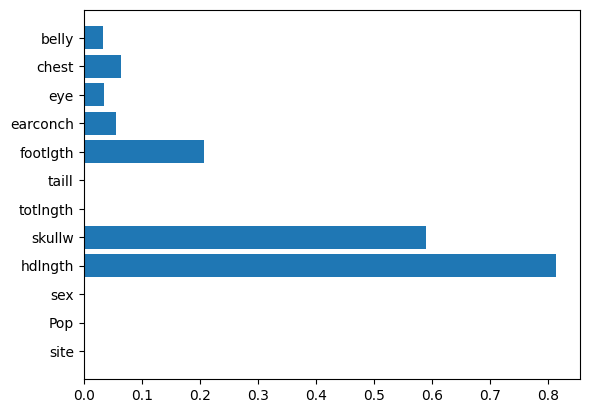

In [21]:
from sklearn.inspection import permutation_importance
rgtree = tree.DecisionTreeRegressor(min_samples_leaf=5)
rgtree.fit(X,y)
result = permutation_importance(rgtree, X, y, n_repeats=100)

feature_importances = result.importances_mean
plt.barh(X.columns, feature_importances)
plt.show()

### Grid Search - poszukiwanie najlepszych parametrów

In [22]:
from sklearn.model_selection import GridSearchCV

rgtree = tree.DecisionTreeRegressor()

param_grid = {'criterion':['squared_error','friedman_mse','absolute_error','poisson'],
    'max_depth': [2,3,4,5,6,7,8,None], 
              'min_samples_leaf': range(5,31)
              }
rgtree_gscv = GridSearchCV(rgtree, param_grid, cv=5)
rgtree_gscv.fit(X, y)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
                         'min_samples_leaf': range(5, 31)})

In [23]:
4*8*26*5

4160

In [24]:
rgtree_gscv.best_params_

{'criterion': 'squared_error', 'max_depth': 3, 'min_samples_leaf': 22}

Score: the coefficient of determination $R^2$

In [25]:
rgtree_gscv.best_score_

0.20322904142806902

Let's plot the tree with best parameters.

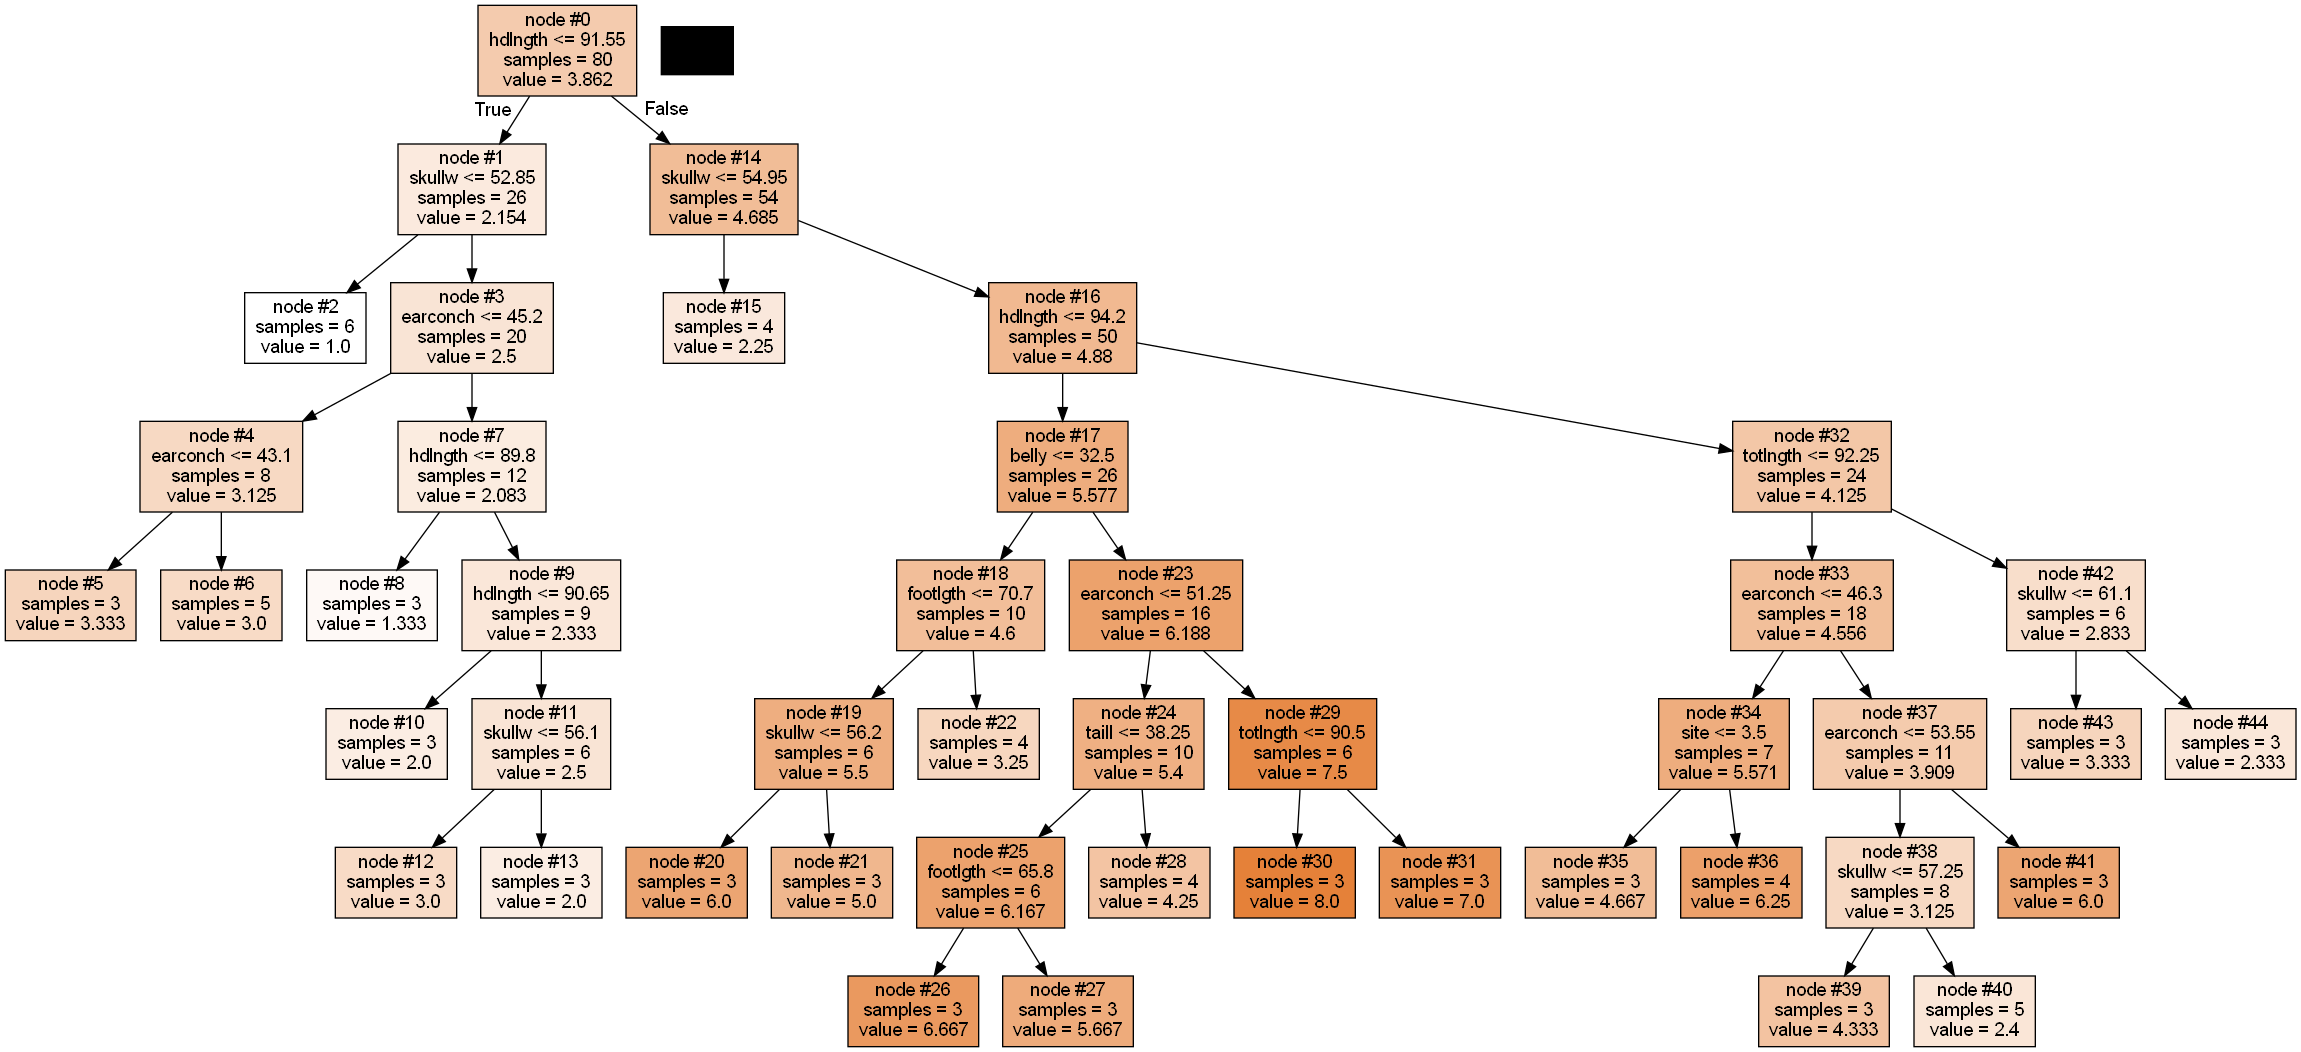

In [26]:
rgtree = tree.DecisionTreeRegressor(criterion ='squared_error', min_samples_leaf=3, max_depth= 22) 
rgtree.fit(X_train, y_train)
dot_data = tree.export_graphviz(rgtree, feature_names=X.columns, out_file=None, 
                                filled=True,impurity=False, node_ids=True)
from IPython.display import Image
import pydotplus
import graphviz
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

### Methody klasy DecisionTreeRegressor

Znamy już metody .fit() oraz .predict(). Zobaczmy inne

Liczba liści

In [27]:
rgtree.get_n_leaves()

23

Głębokość drzewa

In [28]:
rgtree.get_depth()

7

wszystkie parametry modelu

In [29]:
rgtree.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 22,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Ścieżka decyzyjna dla nowych danych

In [30]:
dec_path = rgtree.decision_path(X_test, check_input=True)
print(dec_path)

  (0, 0)	1
  (0, 1)	1
  (0, 3)	1
  (0, 4)	1
  (0, 6)	1
  (1, 0)	1
  (1, 14)	1
  (1, 16)	1
  (1, 17)	1
  (1, 23)	1
  (1, 24)	1
  (1, 25)	1
  (1, 26)	1
  (2, 0)	1
  (2, 14)	1
  (2, 16)	1
  (2, 32)	1
  (2, 33)	1
  (2, 37)	1
  (2, 41)	1
  (3, 0)	1
  (3, 14)	1
  (3, 16)	1
  (3, 32)	1
  (3, 42)	1
  :	:
  (17, 16)	1
  (17, 32)	1
  (17, 33)	1
  (17, 37)	1
  (17, 41)	1
  (18, 0)	1
  (18, 14)	1
  (18, 16)	1
  (18, 32)	1
  (18, 42)	1
  (18, 43)	1
  (19, 0)	1
  (19, 14)	1
  (19, 16)	1
  (19, 17)	1
  (19, 18)	1
  (19, 22)	1
  (20, 0)	1
  (20, 14)	1
  (20, 16)	1
  (20, 32)	1
  (20, 33)	1
  (20, 37)	1
  (20, 38)	1
  (20, 40)	1


$R^2$ dla nowych danych

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor.score

In [31]:
r_2 = rgtree.score(X_test,y_test)
r_2

-2.3208042635658916

Adjusted $R^2$ score: $\bar{R}^2=1-(1-R^2)\frac{n-1}{n-p-1}$

In [32]:
r2adj = 1-(1-r_2)*(len(y_test)-1)/(len(y_test)-len(X_train.columns)-1)
r2adj

-7.302010658914728

### Las losowy


In [33]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
rf.score(X_test,y_test)

-0.5828627906976744